In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import copy
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import expit
import seaborn as sns

# 1. SCM

In [2]:
class SCM:
    def __init__(self) -> None:

        self.equations = {}
        self.graph = nx.DiGraph()
        
    def add_variable(self, name: str, parents: list, equation) -> None:
        self.equations[name] = equation
        self.graph.add_node(name)
        for parent in parents:
            self.graph.add_edge(parent, name)
            
    def sample(self, n_samples: int) -> pd.DataFrame:
        df = pd.DataFrame(index=range(n_samples))
        topo_order = list(nx.topological_sort(self.graph))
        for node in topo_order:
            df[node] = self.equations[node](df)
        return df
        
    def do_operator(self, interventions: dict) -> 'SCM':
        new_scm = copy.deepcopy(self)
        
        for var, value in interventions.items():
            if var in new_scm.equations:
                new_scm.equations[var] = lambda df, val=value: np.full(len(df), val)
                incoming_edges = list(new_scm.graph.in_edges(var))
                new_scm.graph.remove_edges_from(incoming_edges)
                
        return new_scm
        
    def plot_graph(self, title: str) -> None:
        plt.figure(figsize=(8, 6))
        
        pos = nx.spring_layout(self.graph, seed=42)      
        nx.draw_networkx_nodes(self.graph, pos, node_size=1000, node_color='lightblue', edgecolors='black')       
        nx.draw_networkx_labels(self.graph, pos, font_size=11, font_weight='bold')
        nx.draw_networkx_edges(self.graph, pos, arrowstyle='-|>', arrowsize=40, edge_color='gray', width=2, arrows=True)
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# 2. Course Impact

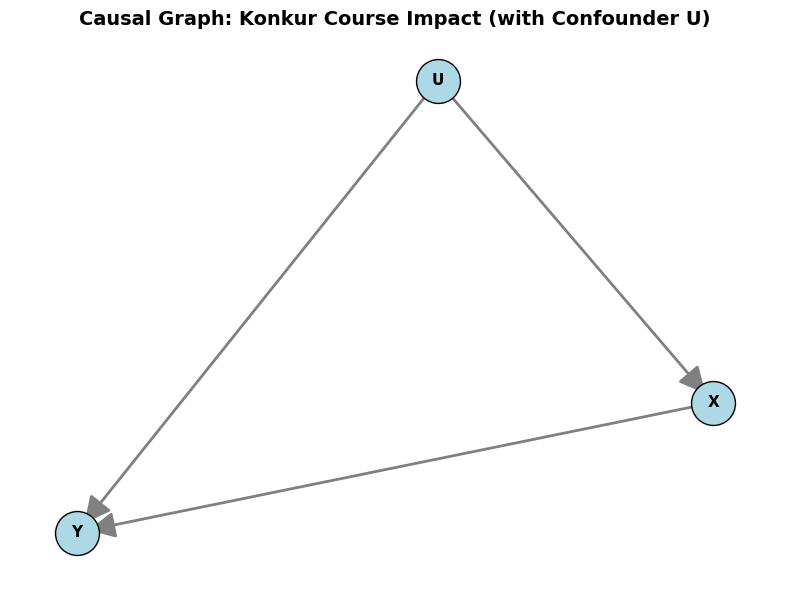

In [3]:
konkur_scm = SCM()

konkur_scm.add_variable('U', [], lambda df: np.random.normal(0, 1, len(df)))
konkur_scm.add_variable('X', ['U'], lambda df: (7 * df['U'] + np.random.normal(0, 1, len(df)) > 0).astype(int))
konkur_scm.add_variable('Y', ['X', 'U'], lambda df: 3 * df['X'] + 2 * df['U'] + np.random.normal(0, 1, len(df)))

konkur_scm.plot_graph("Causal Graph: Konkur Course Impact (with Confounder U)")

In [4]:
np.random.seed(42)
obs_data = konkur_scm.sample(10000)

mean_y_x1 = obs_data[obs_data['X'] == 1]['Y'].mean()
mean_y_x0 = obs_data[obs_data['X'] == 0]['Y'].mean()
obs_diff = mean_y_x1 - mean_y_x0

print(f"Observational Difference (E[Y|X=1] - E[Y|X=0]): {obs_diff:.4f}")

Observational Difference (E[Y|X=1] - E[Y|X=0]): 6.2270


In [5]:
scm_do_x1 = konkur_scm.do_operator({'X': 1})
data_do_x1 = scm_do_x1.sample(10000)

scm_do_x0 = konkur_scm.do_operator({'X': 0})
data_do_x0 = scm_do_x0.sample(10000)

ate = data_do_x1['Y'].mean() - data_do_x0['Y'].mean()
print(f"True Causal Effect (ATE): {ate:.4f}")

True Causal Effect (ATE): 2.9765


# 3. Smoking

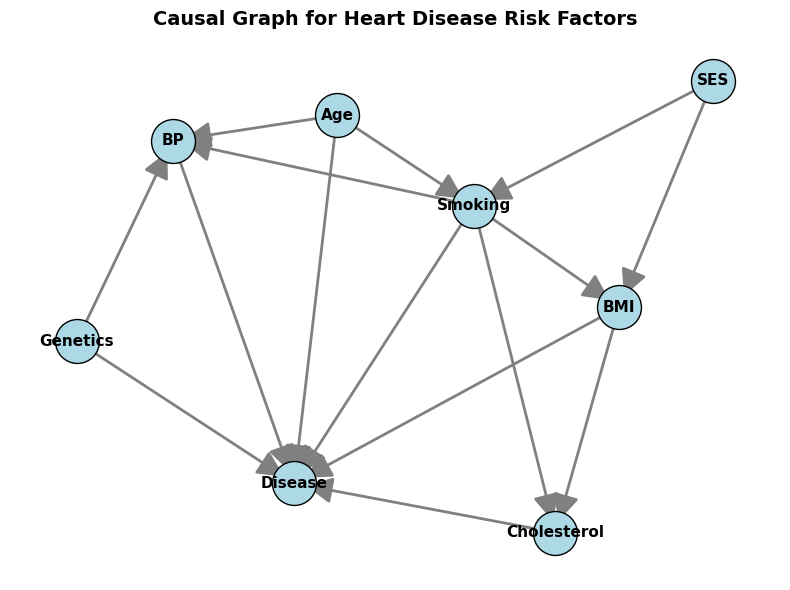

In [6]:
heart_scm = SCM()

heart_scm.add_variable('Age', [], lambda df: np.random.normal(50, 10, len(df)))
heart_scm.add_variable('SES', [], lambda df: np.random.normal(0, 1, len(df)))
heart_scm.add_variable('Genetics', [], lambda df: np.random.normal(0, 1, len(df)))

# Smoking = 1 if eps_smoke < sigmoid(-2 + 0.03*Age - 0.5*SES)
def smoking_eq(df):
    prob = expit(-2 + 0.03 * df['Age'] - 0.5 * df['SES'])
    eps = np.random.uniform(0, 1, len(df))
    return (eps < prob).astype(int)

heart_scm.add_variable('Smoking', ['Age', 'SES'], smoking_eq)

heart_scm.add_variable('BMI', ['Smoking', 'SES'], lambda df: 25 + 2 * df['Smoking'] - df['SES'] + np.random.normal(0, 3, len(df)))

heart_scm.add_variable('BP', ['Smoking', 'Age', 'Genetics'], lambda df: 120 + 5 * df['Smoking'] + 0.3 * df['Age'] + 2 * df['Genetics'] + np.random.normal(0, 10, len(df)))

heart_scm.add_variable('Cholesterol', ['Smoking', 'BMI'], lambda df: 180 + 10 * df['Smoking'] - 0.5 * df['BMI'] + np.random.normal(0, 15, len(df)))

heart_scm.add_variable('Disease', ['Smoking', 'Age', 'BMI', 'BP', 'Cholesterol', 'Genetics'], 
                       lambda df: expit(-15 + 0.6 * df['Smoking'] + 0.02 * df['Age'] + 0.01 * df['BMI'] + 
                                        0.03 * df['BP'] + 0.04 * df['Cholesterol'] + 0.2 * df['Genetics']))

heart_scm.plot_graph("Causal Graph for Heart Disease Risk Factors")

In [7]:
np.random.seed(42)
population = 100000

obs_heart = heart_scm.sample(population)

heart_do_s1 = heart_scm.do_operator({'Smoking': 1}).sample(population)
heart_do_s0 = heart_scm.do_operator({'Smoking': 0}).sample(population)

# ATE
ate_heart = heart_do_s1['Disease'].mean() - heart_do_s0['Disease'].mean()

# ATT
is_smoker_indices = obs_heart[obs_heart['Smoking'] == 1].index
att_heart = heart_do_s1.loc[is_smoker_indices, 'Disease'].mean() - heart_do_s0.loc[is_smoker_indices, 'Disease'].mean()

# CATE
age_over_55_indices = obs_heart[obs_heart['Age'] > 55].index
age_under_55_indices = obs_heart[obs_heart['Age'] <= 55].index

cate_over_55 = heart_do_s1.loc[age_over_55_indices, 'Disease'].mean() - heart_do_s0.loc[age_over_55_indices, 'Disease'].mean()
cate_under_55 = heart_do_s1.loc[age_under_55_indices, 'Disease'].mean() - heart_do_s0.loc[age_under_55_indices, 'Disease'].mean()

print(f"ATE: {ate_heart:.4f}")
print(f"ATT: {att_heart:.4f}")
print(f"CATE (Age > 55): {cate_over_55:.4f}")
print(f"CATE (Age <= 55): {cate_under_55:.4f}")

ATE: 0.0962
ATT: 0.0967
CATE (Age > 55): 0.0966
CATE (Age <= 55): 0.0961


# 4. Website Layout

In [ ]:
df = pd.read_csv('../data/website_engagement_data.csv')
df

,user_id,age_group,layout,time_spent
0,1001,Young,Old_Layout,13.68
1,1002,Older,New_Layout,6.76
2,1003,Older,Old_Layout,4.66
3,1004,Older,New_Layout,8.55
4,1005,Young,New_Layout,19.37
...,...,...,...,...
995,1996,Young,Old_Layout,14.15
996,1997,Older,Old_Layout,6.53
997,1998,Young,Old_Layout,18.13
998,1999,Older,New_Layout,5.62


In [9]:
# New_Layout = 1 , Old_Layout = 0
df['layout_code'] = (df['layout'] == 'New_Layout').astype(int)
# Young = 1 , Older = 0
df['age_code'] = (df['age_group'] == 'Young').astype(int)
df

,user_id,age_group,layout,time_spent,layout_code,age_code
0,1001,Young,Old_Layout,13.68,0,1
1,1002,Older,New_Layout,6.76,1,0
2,1003,Older,Old_Layout,4.66,0,0
3,1004,Older,New_Layout,8.55,1,0
4,1005,Young,New_Layout,19.37,1,1
...,...,...,...,...,...,...
995,1996,Young,Old_Layout,14.15,0,1
996,1997,Older,Old_Layout,6.53,0,0
997,1998,Young,Old_Layout,18.13,0,1
998,1999,Older,New_Layout,5.62,1,0


In [10]:
print(f"Mean time spent for all users in NEW layout: {df[df['layout_code'] == 1]['time_spent'].mean():.4} minutes")
print(f"Mean time spent for all users in OLD layout: {df[df['layout_code'] == 0]['time_spent'].mean():.4} minutes")

Mean time spent for all users in NEW layout: 9.731 minutes
Mean time spent for all users in OLD layout: 12.5 minutes


In [11]:
print(f"Mean time spent for old users in NEW layout: {df[(df['layout_code'] == 1) & (df['age_code'] == 0)]['time_spent'].mean():.4} minutes")
print(f"Mean time spent for old users in OLD layout: {df[(df['layout_code'] == 0) & (df['age_code'] == 0)]['time_spent'].mean():.4} minutes")

Mean time spent for old users in NEW layout: 8.035 minutes
Mean time spent for old users in OLD layout: 4.88 minutes


In [12]:
print(f"Mean time spent for young users in NEW layout: {df[(df['layout_code'] == 1) & (df['age_code'] == 1)]['time_spent'].mean():.4} minutes")
print(f"Mean time spent for young users in OLD layout: {df[(df['layout_code'] == 0) & (df['age_code'] == 1)]['time_spent'].mean():.4} minutes")

Mean time spent for young users in NEW layout: 18.05 minutes
Mean time spent for young users in OLD layout: 15.03 minutes


In [13]:
X_simple = sm.add_constant(df['layout_code'])
model_simple = sm.OLS(df['time_spent'], X_simple).fit()
print(model_simple.summary())

naive_coef = model_simple.params['layout_code']
print(f"Naive Coef: {naive_coef}")

                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     101.7
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           7.64e-23
Time:                        18:55:40   Log-Likelihood:                -2877.8
No. Observations:                1000   AIC:                             5760.
Df Residuals:                     998   BIC:                             5769.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          12.5017      0.207     60.422      

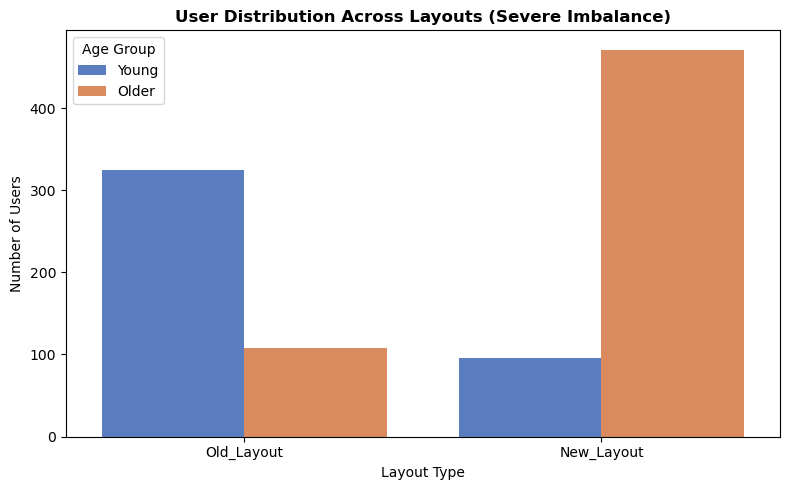

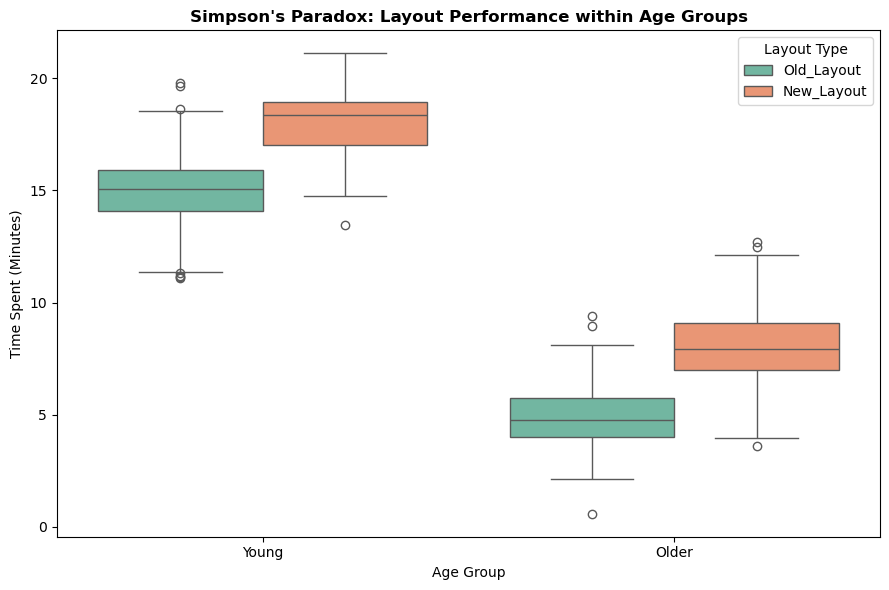

In [14]:
# part 2
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='layout', hue='age_group', palette='muted')
plt.title("User Distribution Across Layouts (Severe Imbalance)", fontsize=12, fontweight='bold')
plt.xlabel("Layout Type")
plt.ylabel("Number of Users")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='age_group', y='time_spent', hue='layout', palette='Set2')
plt.title("Simpson's Paradox: Layout Performance within Age Groups", fontsize=12, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Time Spent (Minutes)")
plt.legend(title="Layout Type")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     4231.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:55:40   Log-Likelihood:                -1801.4
No. Observations:                1000   AIC:                             3609.
Df Residuals:                     997   BIC:                             3624.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.9332      0.112     44.073      

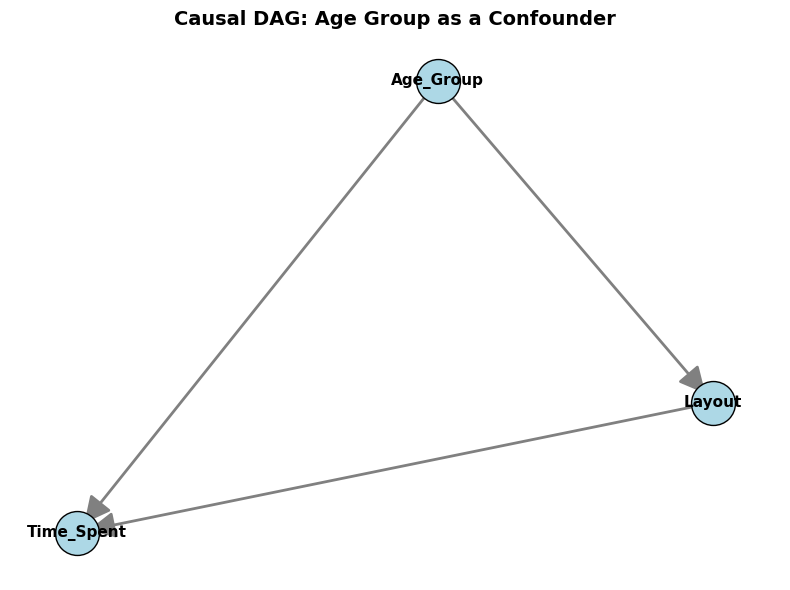

In [ ]:
# part 3
X_controlled = sm.add_constant(df[['layout_code', 'age_code']])
model_controlled = sm.OLS(df['time_spent'], X_controlled).fit()
print(model_controlled.summary())

true_causal_coef = model_controlled.params['layout_code']
print(f"\nTrue Causal Coefficient for New Layout (Controlled): {true_causal_coef:.4f}")

website_scm = SCM()

website_scm.add_variable('Age_Group', parents=[], equation=lambda df: None)

website_scm.add_variable('Layout', parents=['Age_Group'], equation=lambda df: None)

website_scm.add_variable('Time_Spent', parents=['Age_Group', 'Layout'], equation=lambda df: None)

website_scm.plot_graph("Causal DAG: Age Group as a Confounder")

In [16]:
# part 4
np.random.seed(42) 

df_placebo = df.copy()

df_placebo['layout_shuffled'] = np.random.permutation(df_placebo['layout_code'].values)

X_placebo = sm.add_constant(df_placebo[['layout_shuffled', 'age_code']])
model_placebo = sm.OLS(df_placebo['time_spent'], X_placebo).fit()
print(model_placebo.summary())

placebo_coef = model_placebo.params['layout_shuffled']
placebo_p = model_placebo.pvalues['layout_shuffled']
print(f"\nPlacebo Test Coef (Shuffled): {placebo_coef:.4f}")
print(f"Placebo P-value: {placebo_p:.4f}")

                            OLS Regression Results                            
Dep. Variable:             time_spent   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     2259.
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:55:41   Log-Likelihood:                -2071.0
No. Observations:                1000   AIC:                             4148.
Df Residuals:                     997   BIC:                             4163.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.3242      0.107     